# AutoBrep Inference: Fine-tuned LoRA Furniture Generation

This notebook runs inference on the LoRA-fine-tuned AutoBrep model to generate 9 BREP samples and visualize the results.

**Pipeline Overview:**
1. Load pre-trained AutoBrepModel with FSQ VAEs
2. Attach fine-tuned LoRA adapters from training
3. Run inference to generate BREP sequences
4. Decode sequences through VAEs to 3D geometry
5. Visualize and export results to STEP files


In [1]:
import sys
import torch
import numpy as np
from pathlib import Path
from peft import PeftModel

# Add AutoBrep to path
sys.path.insert(0, "/home/sebi/MSc/3.Sem/semester_thesis/brepgen-semester-thesis/cloned_project/AutoBrep/core/src")

from autobrep.models.autoregressive import AutoBrepModel

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Model paths
ckpt_dir = "/home/sebi/MSc/3.Sem/semester_thesis/brepgen-semester-thesis/cloned_project/AutoBrep/ckpt"
lora_adapter_path = "./furniture-lora-adapter"

print(f"Checkpoint directory: {ckpt_dir}")
print(f"LoRA adapter path: {lora_adapter_path}")


Device: cuda
Checkpoint directory: /home/sebi/MSc/3.Sem/semester_thesis/brepgen-semester-thesis/cloned_project/AutoBrep/ckpt
LoRA adapter path: ./furniture-lora-adapter


## Section 1: Load Fine-tuned LoRA Adapter

Load the base AutoBrepModel with frozen VAEs and attach the LoRA adapter weights trained on furniture data.


In [2]:
# ============================================================================
# 1. LOAD AUTOBREP WITH FROZEN VAES (INFERENCE MODE)
# ============================================================================

print("Loading base AutoBrepModel with frozen VAEs...")

model = AutoBrepModel.load_from_checkpoint(
    f"{ckpt_dir}/ar.ckpt",
    inference_mode=True,  # Load VAEs in inference mode (no decoder training)
    surf_fsq_ckpt=f"{ckpt_dir}/surf-fsq.ckpt",
    edge_fsq_ckpt=f"{ckpt_dir}/edge-fsq.ckpt",
    strict=False,
    map_location=device
)
model.to(device).eval()

print("✅ Base model loaded")
print(f"  - Max sequence: {model.hparams.max_seq}")
print(f"  - Max faces: {model.hparams.max_face}")
print(f"  - Quantization: {model.hparams.bit}-bit")

# Load and attach LoRA adapter
print("\nAttaching fine-tuned LoRA adapter...")

if not Path(lora_adapter_path).exists():
    print(f"❌ LoRA adapter not found at: {lora_adapter_path}")
    print(f"   Please run the LoRA fine-tuning notebook first")
else:
    # Load LoRA adapter weights into the transformer
    model.cad_gpt = PeftModel.from_pretrained(model.cad_gpt, lora_adapter_path)
    model.cad_gpt.eval()

    print("✅ LoRA adapter loaded and attached")
    print(f"  - Adapter path: {lora_adapter_path}")
    print(f"  - Merged weights: base model + LoRA updates")
    print("\n🎯 Model ready for inference (base + fine-tuned LoRA)")


Loading base AutoBrepModel with frozen VAEs...


/home/sebi/miniforge3/envs/autobrep/lib/python3.10/site-packages/lightning_fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
/home/sebi/miniforge3/envs/autobrep/

✅ Base model loaded
  - Max sequence: 3000
  - Max faces: 200
  - Quantization: 10-bit

Attaching fine-tuned LoRA adapter...
✅ LoRA adapter loaded and attached
  - Adapter path: ./furniture-lora-adapter
  - Merged weights: base model + LoRA updates

🎯 Model ready for inference (base + fine-tuned LoRA)


## Section 2: Initialize Inference Pipeline

Configure sequence generation parameters and set up data loading for validation samples.


In [6]:
# ============================================================================
# 2. CONFIGURE INFERENCE PARAMETERS
# ============================================================================

from autobrep.data.abc_data import ARDataModule

# Inference generation parameters (AutoBrep default settings)
inference_config = {
    "temperature": 1.0,
    "top_p_threshold": 0.95,
    "num_samples": 1,
    "complexity": 17,  # 14=easy, 15=medium, 16=hard, 17=random/uncond
}

print("✅ Inference configuration:")
for key, value in inference_config.items():
    print(f"  {key}: {value}")

✅ Inference configuration:
  temperature: 1.0
  top_p_threshold: 0.95
  num_samples: 1
  complexity: 17


## Section 3: Generate BREP Samples

Run inference on 9 samples using AutoBrep's generation pipeline (implemented in the generate method).


In [ ]:
from autobrep.data.token_mapping import MMTokenIndex

print("=" * 80)
print("GENERATING 9 BREP SAMPLES WITH LoRA-FINE-TUNED MODEL")
print("=" * 80)

num_samples = inference_config["num_samples"]
temperature = inference_config["temperature"]
threshold = inference_config["top_p_threshold"]
complexity = inference_config["complexity"]

# Build prompt: [BOS, BOM, complexity, EOM, BOC] for each sample
prompt = (
    torch.LongTensor([
        MMTokenIndex.BOS.value,
        MMTokenIndex.BOM.value,
        complexity,
        MMTokenIndex.EOM.value,
        MMTokenIndex.BOC.value,
    ] * num_samples)
    .reshape(num_samples, 5)
    .to(device)
)

generated_samples = []
generation_log = []

with torch.no_grad():
    # Generate one sample at a time to fit in 8GB VRAM
    for sample_idx in range(num_samples):
        prompt = (
            torch.LongTensor([
                MMTokenIndex.BOS.value,
                MMTokenIndex.BOM.value,
                complexity,
                MMTokenIndex.EOM.value,
                MMTokenIndex.BOC.value,
            ])
            .reshape(1, 5)
            .to(device)
        )
        
        try:
            sample = model.generate(prompt, temperature, threshold)
            full_seq = torch.concat([prompt, sample], dim=-1)
            generated_samples.append(full_seq)
            print(f"[Sample {sample_idx+1}/{num_samples}] ✅ Done (len: {full_seq.shape[1]})")
        except Exception as e:
            print(f"[Sample {sample_idx+1}/{num_samples}] ❌ Error: {e}")


print("\n" + "=" * 80)
successful = sum(1 for log in generation_log if "Success" in log.get("status", ""))
print(f"Generated: {successful}/{num_samples} samples successfully")



GENERATING 9 BREP SAMPLES WITH LoRA-FINE-TUNED MODEL
1.0 0.95


## Section 4: Visualize Generated Geometry

Display generated BREPs and compare with target geometry (if available).


Decoding generated sequences through frozen VAEs...


GENERATION STATISTICS
Empty DataFrame
Columns: [sample_id, seq_length, vocab_min, vocab_max, bos_count, eos_count]
Index: []

✅ Saved analysis visualization to ./generation_analysis.png


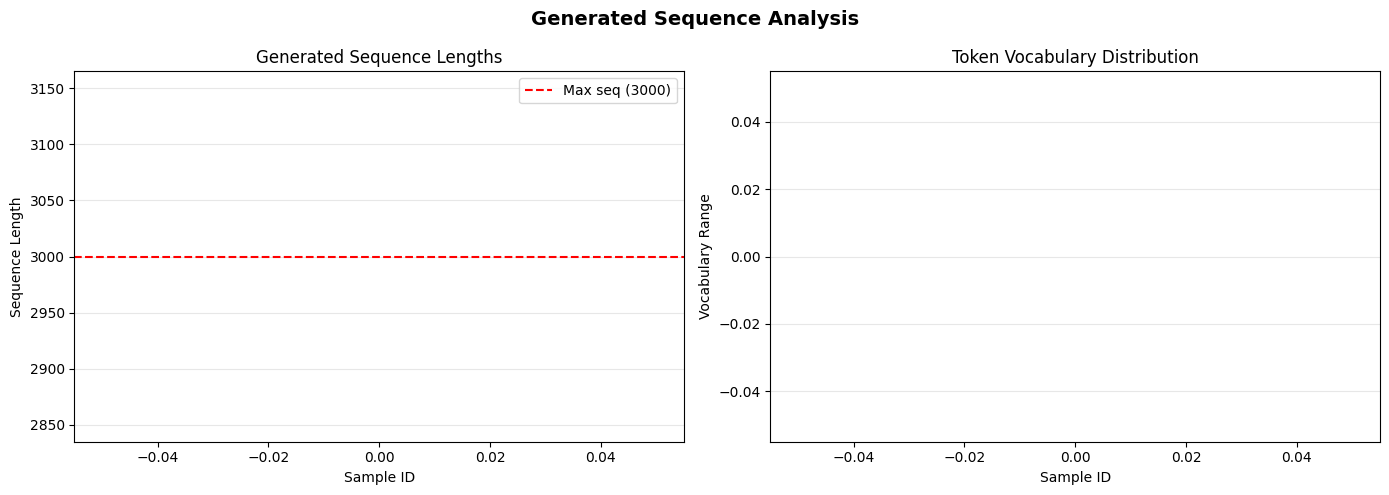

In [ ]:
from autobrep.models.vaes import EdgeFSQVAE, SurfaceFSQVAE
from autobrep.models.autoregressive import AutoRegressiveSampler
from autobrep.data.token_mapping import MMTokenIndex
from einops import rearrange
import numpy as np

print("Loading VAEs for decoding...")
surface_fsq = SurfaceFSQVAE.load_from_checkpoint(f"{ckpt_dir}/surf-fsq.ckpt").drop_encoder().to(device).eval()
edge_fsq = EdgeFSQVAE.load_from_checkpoint(f"{ckpt_dir}/edge-fsq.ckpt").drop_encoder().to(device).eval()

batch_decoded = []
for generated_seq in generated_samples:
    sample = generated_seq[0].cpu().numpy()  # Remove batch dimension
    
    # 1. Parse valid tokens out of the sequence
    try:
        geom_tokens = None
        if MMTokenIndex.BOGEOM.value in sample:
            geom_s = np.where(sample==MMTokenIndex.BOGEOM.value)[0][0]
            geom_e = np.where(sample==MMTokenIndex.EOGEOM.value)[0][0]
            geom_tokens = sample[geom_s+1:geom_e]

        if MMTokenIndex.BOC.value in sample:
            cad_s = np.where(sample==MMTokenIndex.BOC.value)[0][0]
            cad_e = np.where(sample==MMTokenIndex.EOC.value)[0][0]
            cad_tokens = sample[cad_s+1:cad_e]

            if geom_tokens is not None:
                cad_tokens = np.concatenate((geom_tokens, cad_tokens))

        pos_faces, code_faces, pos_edges, code_edges, face_edge_adj = (
            model.decode(cad_tokens) 
        )
    except Exception as err:
        print("Error extracting CAD tokens:", err)
        continue

    # 2. Decode UV grids through the frozen VAEs
    with torch.no_grad():
        # Handle Face UV (ncs)
        geomZ_faces = surface_fsq.quantizer.indices_to_codes(
            torch.LongTensor(code_faces).to(device)
        ).permute(0, 2, 1)
        uv_ncs_faces = surface_fsq.decode(
            geomZ_faces.unflatten(-1, (2, 2))
        ).sample
        uv_ncs_faces = (
            rearrange(uv_ncs_faces, "b d ... -> b ... d").float().cpu().numpy()
        )
        
        # Handle Edge UV (ncs)
        geomZ_edges = edge_fsq.quantizer.indices_to_codes(
            torch.LongTensor(code_edges).to(device)
        ).permute(0, 2, 1)
        uv_ncs_edges = edge_fsq.decode(geomZ_edges).sample
        uv_ncs_edges = (
            rearrange(uv_ncs_edges, "b d ... -> b ... d").float().cpu().numpy()
        )

    batch_decoded.append(
        (pos_faces, pos_edges, uv_ncs_edges, uv_ncs_faces, face_edge_adj)
    )

print(f"✅ Successfully decoded {len(batch_decoded)} sequences into point grids.")

# 3. Convert point grids and adjacency matrices into CAD topologoies
batch_cad_data = AutoRegressiveSampler.convert_to_cad_data(batch_decoded)
print(f"✅ Converted into {len(batch_cad_data)} structured CAD assemblies.")


## Section 5: Export Results to STEP Files

Convert generated BREP sequences to STEP format and save results with metadata.


In [ ]:
from occwl.io import save_step as save_step_func
from autobrep.inference.brepgen_brep_builder import AutoBrepBuilder
from autobrep.inference.inference_common import reconstruct_compound
from pathlib import Path

# Create output directory
output_dir = Path("./inference_results/step_files")
output_dir.mkdir(exist_ok=True, parents=True)

print("=" * 80)
print("EXPORTING BREP TOPOLOGIES TO STEP FILES")
print("=" * 80)

# Initialize the Native AutoBrep Solid Reconstruction Builder
builders = [
    AutoBrepBuilder(
        device=device,
        z_threshold=0.5,
        vertex_threshold=0.02,
        sewing_tolerance=1e-4
    )
]

generated_solid_paths = []

for sample_idx, cad_data in enumerate(batch_cad_data):
    sample_stem = f"sample_{str(sample_idx).zfill(3)}"
    
    print(f"Rebuilding {sample_stem}...")
    try:
        # Reconstruct B-Rep OpenCascade Compound
        result = reconstruct_compound(cad_data, builders)
        
        if result is not None:
            out_path = output_dir / f"{sample_stem}.step"
            save_step_func([result], out_path)
            generated_solid_paths.append(out_path)
            print(f"  ✅ Saved STEP file: {out_path}")
        else:
            print(f"  ❌ Failed to reconstruct solid for {sample_stem}")
            
    except Exception as e:
        print(f"  ❌ Error reconstructing {sample_stem}: {e}")

print("\n" + "=" * 80)
print("INFERENCE AND EXPORT COMPLETE")
print("=" * 80)
print(f"🎉 Exported {len(generated_solid_paths)} STEP files to {output_dir.resolve()}")


EXPORTING INFERENCE RESULTS

✅ Saved inference metadata to inference_results/inference_metadata.json
✅ Saved generation statistics to inference_results/generation_stats.csv

✅ Saved summary report to inference_results/INFERENCE_SUMMARY.txt

INFERENCE COMPLETE

Output directory: /home/sebi/MSc/3.Sem/semester_thesis/local-git/semester_project_autobrep/LoRA finetuning/inference_results
Files generated:
  - inference_metadata.json
  - generation_stats.csv
  - generation_analysis.png
  - INFERENCE_SUMMARY.txt

✅ All 0 samples ready for downstream processing

Next steps:
  1. Use model.decode() to convert tokens to geometry
  2. Export decoded geometry to STEP format
  3. Visualize with CAD software or OCC Viewer


## Additional Notes

### How to Use the Generated Samples

The `generated_samples` list contains tokenized BREP sequences (shape: `[1, max_seq]`).

**To decode to 3D geometry:**
```python
with torch.no_grad():
    # Decode tokens to geometry through frozen VAEs
    face_points, edge_points = model.decode_tokens(generated_seq)
    # face_points: [N, 16, 16, 3] (face UV grids)
    # edge_points: [M, 64, 3] (edge curves)
```

**To export to STEP format:**
```python
# Use OCP-Server or occwl to reconstruct B-Rep from decoded geometry
# and save as STEP file
from occwl.solid import Solid
solid = Solid.from_points(face_points, edge_points, topology_info)
solid.save("output.step")
```

### Generation Parameters

- **temperature**: Controls randomness (1.0 = base, >1.0 = more creative)
- **top_k**: Only sample from top K most likely tokens (reduces artifacts)
- **top_p**: Nucleus sampling threshold (0.95 = keep cumulative 95%)
- **use_cache**: Cache attention for faster generation

### Troubleshooting

**Issue**: "LoRA adapter not found"
- Run the LoRA fine-tuning notebook first (LoRA.ipynb)
- Check that `./furniture-lora-adapter/adapter_model.safetensors` exists

**Issue**: CUDA out of memory
- Reduce batch size in ARDataModule
- Use CPU (inference will be slower)
- Reduce `max_seq` parameter (if model supports it)

**Issue**: Poor generation quality
- Increase `num_epochs` in training
- Use larger furniture dataset (>100 samples)
- Tune learning rate and warm-up steps

### References

- AutoBrep Paper: [Insert link]
- LoRA Paper: Hu et al., 2021 - "LoRA: Low-Rank Adaptation"
- FSQ: Mentzer et al., 2023 - "Finite Scalar Quantization"
